In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

from methods.data_utils import load_data, pre_avg, \
    compute_returns, filter_day, summarize_data
from methods.plotting import set_style
set_style()


In [9]:
markets = ["EURUSD", "USDJPY", "USDZAR", "XAUUSD"]

eurusd = load_data(market = markets[0])
usdjpy = load_data(market = markets[1])
usdzar = load_data(market = markets[2])
xauusd = load_data(market = markets[3])

data = {"EURUSD": eurusd, 
        "USDJPY": usdjpy, 
        "USDZAR": usdzar, 
        "XAUUSD": xauusd}


In [10]:
for name in data:
    data[name] = pre_avg(data[name], k=10)
print(data["EURUSD"].head())

                                      bid      ask  volume  mid_price  \
datetime                                                                
2026-02-01 22:03:44.545000+00:00  1.18503  1.18537       0   1.185200   
2026-02-01 22:03:53.271000+00:00  1.18503  1.18554       0   1.185285   
2026-02-01 22:04:09.168000+00:00  1.18502  1.18554       0   1.185280   
2026-02-01 22:04:13.029000+00:00  1.18502  1.18556       0   1.185290   
2026-02-01 22:04:18.498000+00:00  1.18502  1.18537       0   1.185195   

                                   pre_avg  
datetime                                    
2026-02-01 22:03:44.545000+00:00  1.185223  
2026-02-01 22:03:53.271000+00:00  1.185231  
2026-02-01 22:04:09.168000+00:00  1.185240  
2026-02-01 22:04:13.029000+00:00  1.185247  
2026-02-01 22:04:18.498000+00:00  1.185248  


In [11]:
for name in data:
    data[name] = compute_returns(data[name])

print(data["EURUSD"].head())

                                      bid      ask  volume  mid_price  \
datetime                                                                
2026-02-01 22:03:53.271000+00:00  1.18503  1.18554       0   1.185285   
2026-02-01 22:04:09.168000+00:00  1.18502  1.18554       0   1.185280   
2026-02-01 22:04:13.029000+00:00  1.18502  1.18556       0   1.185290   
2026-02-01 22:04:18.498000+00:00  1.18502  1.18537       0   1.185195   
2026-02-01 22:04:20.264000+00:00  1.18507  1.18537       0   1.185220   

                                   pre_avg             r  
datetime                                                  
2026-02-01 22:03:53.271000+00:00  1.185231  9.000000e-06  
2026-02-01 22:04:09.168000+00:00  1.185240  8.000000e-06  
2026-02-01 22:04:13.029000+00:00  1.185247  7.500000e-06  
2026-02-01 22:04:18.498000+00:00  1.185248  5.000000e-07  
2026-02-01 22:04:20.264000+00:00  1.185252  4.000000e-06  


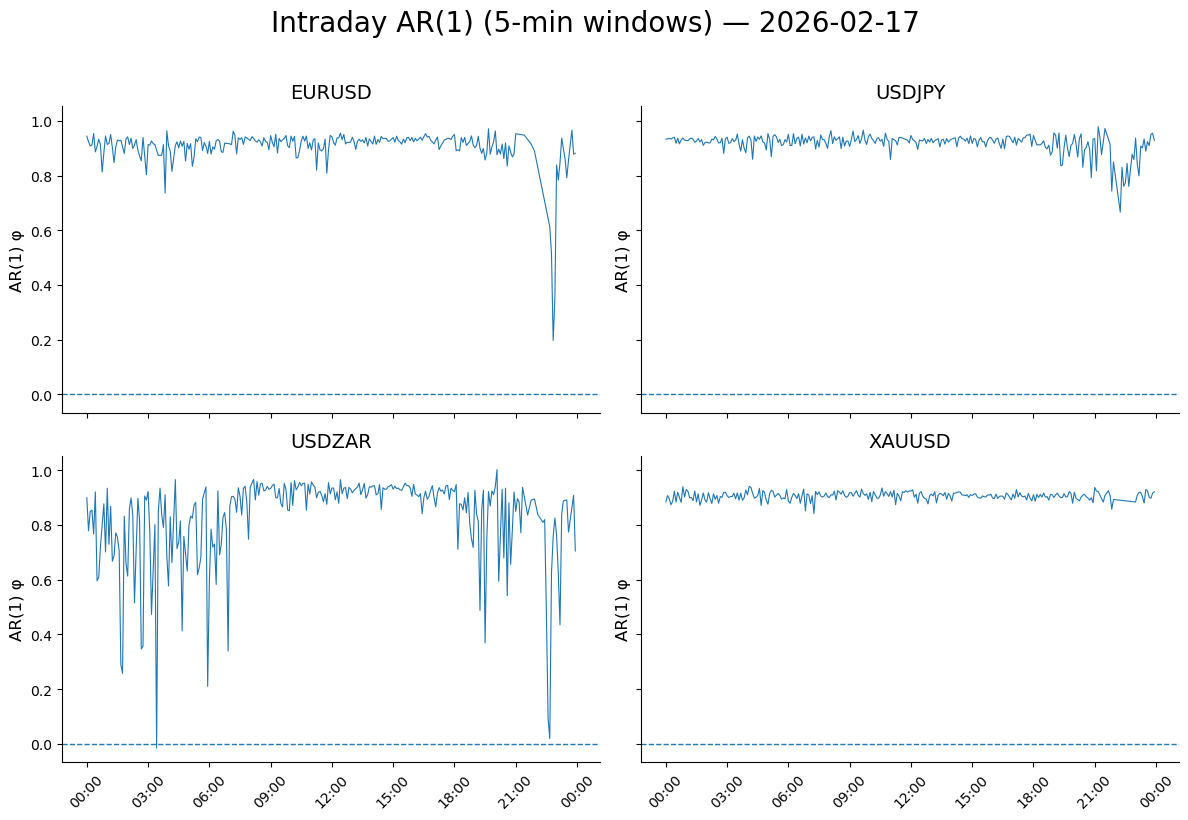

In [12]:
import statsmodels.api as sm

day = "2026-02-17"     
window = "5min"
min_obs = 50 

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (name, df) in zip(axes, data.items()):

    # 1) filtrer dagen (fungerer når df har datetime-index i UTC)
    df_day = df.loc[day].copy()

    # 2) group i 5-min intervaller
    groups = df_day.groupby(pd.Grouper(freq=window))

    phi_list = []
    for t, g in groups:
        if len(g) < min_obs:
            continue

        y = g["r"].iloc[1:]
        x = g["r"].shift(1).iloc[1:]

        X = sm.add_constant(x)
        res = sm.OLS(y, X).fit()

        # robust uthenting av phi (unngår å anta posisjon)
        phi = res.params.get("r", res.params.iloc[1])

        phi_list.append((t, phi))

    phi = pd.Series(dict(phi_list)).sort_index()

    ax.plot(phi.index, phi.values)
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_ylabel("AR(1) φ")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", rotation=45)


plt.suptitle(f"Intraday AR(1) (5-min windows) — {day}", y=1.02, fontsize=20)
plt.savefig(f"../plots/ar_1_intraday_{day}.pdf", bbox_inches="tight", format="pdf")
plt.tight_layout()
plt.show()